# 준비 단계

In [ ]:
# 라이브러리 임포트
from google.colab import drive
import pandas as pd
import sqlite3
import os
from tqdm import tqdm
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# base 코호트 구축

In [ ]:
# 1) ICU stay, Admissions, Patients 불러오기
path_icustays = '/content/drive/MyDrive/Colab/DataAnalytics/icu/icu_icustays.csv'
path_admissions = '/content/drive/MyDrive/Colab/DataAnalytics/icu/icu_admissions.csv'
path_patients   = '/content/drive/MyDrive/Colab/DataAnalytics/icu/icu_patients.csv'

icustays   = pd.read_csv(path_icustays, parse_dates=['intime', 'outtime'])
admissions = pd.read_csv(path_admissions, parse_dates=['admittime', 'dischtime'])
patients   = pd.read_csv(path_patients)

# 2) ICU 중심 병합
base = (
    icustays
    .merge(admissions, on=['subject_id','hadm_id'], how='inner', suffixes=('_icu','_adm'))
    .merge(patients, on='subject_id', how='inner')
)

# 3) ICU 체류일 계산
base['icu_los_days'] = (base['outtime'] - base['intime']).dt.total_seconds() / (24*3600)

# 4) 코호트 필터링
base = base[
    (base['icu_los_days'] > 2) & # 음수 제거 & 48시간 윈도우를 고려해 2일 이상 입원 환자 데이터만 사용
    (base['icu_los_days'] <= 21) & # LOS > 21일 제거 (초장기 입원 환자)
    (base['anchor_age'] >= 18)  & # 성인 환자만 포함
    (base['hospital_expire_flag'] == 0) & # 사망 환자 제외
    (base['admission_type'].str.strip().ne('ELECTIVE')) & # 선택적 입원 제외
    (base['anchor_year_group'].isin(['2011 - 2013', '2014 - 2016', '2017 - 2019', '2020 - 2022'])) # 2010년대 이후
]

# 5) 중복 제거 (첫 ICU 입실만 유지)
base = base.sort_values('intime').drop_duplicates(subset=['subject_id'], keep='first')

# 6) 48시간 윈도우 생성
base['win_start'] = base['intime']
base['win_end']   = base['intime'] + pd.Timedelta(hours=48)

print("코호트 shape:", base.shape)

코호트 shape: (21072, 30)


In [ ]:
# 약물 필터링
db_path = '/content/drive/MyDrive/Colab/DataAnalytics/MIMIC4-hosp-icu.db'

try:
    conn = sqlite3.connect('temp_cohort_check.db')
    base[['stay_id', 'intime']].to_sql('cohort_for_drug', conn, if_exists='replace', index=False)
    conn.execute(f"ATTACH DATABASE '{db_path}' AS remote_db")

    # 약물 필터링 쿼리
    drug_sql = """
    SELECT DISTINCT t.stay_id
    FROM cohort_for_drug t
    JOIN remote_db.inputevents i ON t.stay_id = i.stay_id
    WHERE i.endtime > t.intime
    """

    valid_drug_stays = pd.read_sql_query(drug_sql, conn)
    conn.close()

    # 필터링 적용
    final_cohort = base[base['stay_id'].isin(valid_drug_stays['stay_id'])].copy()

    # 약물 필터링 이후 상태
    print("-" * 60)
    print(f"약물 필터링 후(Post-Drug) 코호트 크기")
    print(f"   - Shape: {final_cohort.shape}")
    print(f"   - 환자 수: {len(final_cohort):,} 명")
    print("-" * 60)

except Exception as e:
    print(f"[오류] DB 연결 실패: {e}")
    final_cohort = base

------------------------------------------------------------
약물 필터링 후(Post-Drug) 코호트 크기
   - Shape: (18123, 30)
   - 환자 수: 18,123 명
------------------------------------------------------------


In [ ]:
# 연도별 약물 커버리지 확인
print("\n연도별 약물 데이터 보유 비율")
count_pre = base['anchor_year_group'].value_counts().sort_index()
count_post = final_cohort['anchor_year_group'].value_counts().sort_index()

stats_df = pd.DataFrame({'Total': count_pre, 'Drug_Filtered': count_post})
stats_df['Percentage'] = (stats_df['Drug_Filtered'] / stats_df['Total']) * 100
print(stats_df)


연도별 약물 데이터 보유 비율
                   Total  Drug_Filtered  Percentage
anchor_year_group                                  
2011 - 2013         5721           5566   97.290683
2014 - 2016         5748           5541   96.398747
2017 - 2019         5569           5359   96.229126
2020 - 2022         4034           1657   41.075855


In [ ]:
# 정적 변수 결측치 처리
cols_fill = ['marital_status', 'insurance', 'language']
for c in cols_fill:
    if c in final_cohort.columns:
        final_cohort[c] = final_cohort[c].fillna('UNKNOWN')

if 'race' in final_cohort.columns:
    final_cohort['race_simplified'] = final_cohort['race'].apply(
        lambda x: x if x in ['WHITE', 'BLACK/AFRICAN AMERICAN', 'ASIAN', 'HISPANIC/LATINO'] else 'OTHER'
    )

# Vital 10종에 대한 bin별 분포 확인

In [ ]:
# item id 정의
vital_itemids = {
    220045: 'HR',
    220052: 'MAP',
    220210: 'RR',
    220277: 'SpO2',
    223761: 'Temp',
    # 의식 반응
    223900: 'GCS_Verbal',
    223901: 'GCS_Motor',
    220739: 'GCS_Eye',
    228302: 'RASS',
    223791: 'Pain'
}

# chartevents에서 raw vital 10종 추출 (charttime 포함)
conn = sqlite3.connect(db_path)

stay_ids = tuple(final_cohort['stay_id'].unique().tolist())

query = f"""
SELECT stay_id, itemid, charttime, valuenum
FROM chartevents
WHERE itemid IN ({','.join(map(str, vital_itemids.keys()))})
AND stay_id IN ({','.join(map(str, stay_ids))})
"""

chunksize = 300000
raw_list = []

for chunk in tqdm(pd.read_sql_query(query, conn, chunksize=chunksize)):
    chunk = chunk.dropna(subset=['valuenum'])
    chunk['charttime'] = pd.to_datetime(chunk['charttime'], errors='coerce')

    # 48시간 window merge
    chunk = chunk.merge(
        final_cohort[['stay_id','win_start','win_end']],
        on='stay_id', how='inner'
    )
    mask = (chunk['charttime'] >= chunk['win_start']) & (chunk['charttime'] <= chunk['win_end'])

    raw_list.append(chunk.loc[mask, ['stay_id','itemid','charttime','valuenum']])

raw_vital = pd.concat(raw_list, ignore_index=True)
conn.close()

print("raw_vital shape:", raw_vital.shape)
print(raw_vital.head())

0it [00:00, ?it/s]/tmp/ipython-input-2012408867.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['charttime'] = pd.to_datetime(chunk['charttime'], errors='coerce')
1it [00:17, 17.00s/it]/tmp/ipython-input-2012408867.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['charttime'] = pd.to_datetime(chunk['charttime'], errors='coerce')
2it [00:31, 15.66s/it]/tmp/ipython-input-2012408867.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

raw_vital shape: (4343536, 4)
    stay_id  itemid           charttime  valuenum
0  34672098  220277 2162-02-19 19:00:00      99.0
1  34672098  220045 2162-02-19 20:00:00     103.0
2  34672098  220210 2162-02-19 20:00:00      21.0
3  34672098  220277 2162-02-19 20:00:00      93.0
4  34672098  223761 2162-02-19 20:00:00      97.7


In [ ]:
# 이상치 탐색 및 제거

# HR
HR_ID = 220045
hr_df = raw_vital[raw_vital['itemid'] == HR_ID].copy()
hr_outlier = hr_df[(hr_df['valuenum'] < 25) | (hr_df['valuenum'] > 225)]
print("HR 전체 개수:", len(hr_df))
print("HR 이상치 개수:", len(hr_outlier))
print("이상치 비율:", len(hr_outlier) / len(hr_df) * 100, "%")
raw_vital = raw_vital.drop(hr_outlier.index)

# RR
RR_ID = 220210
rr_df = raw_vital[raw_vital['itemid'] == RR_ID].copy()
rr_outlier = rr_df[(rr_df['valuenum'] < 7) | (rr_df['valuenum'] > 40)]
print("RR 전체 개수:", len(rr_df))
print("RR 이상치 개수:", len(rr_outlier))
print("이상치 비율:", len(rr_outlier) / len(rr_df) * 100, "%")
raw_vital = raw_vital.drop(rr_outlier.index)

# SpO2
SPO2_ID = 220277
spo2_df = raw_vital[raw_vital['itemid'] == SPO2_ID].copy()
spo2_outlier = spo2_df[(spo2_df['valuenum'] < 50) | (spo2_df['valuenum'] > 120)]
print("SpO2 전체 개수:", len(spo2_df))
print("SpO2 이상치 개수:", len(spo2_outlier))
print("이상치 비율:", len(spo2_outlier) / len(spo2_df) * 100, "%")
raw_vital = raw_vital.drop(spo2_outlier.index)

# Temp
TEMP_ID = 223761
temp_df = raw_vital[raw_vital['itemid'] == TEMP_ID].copy()
temp_outlier = temp_df[(temp_df['valuenum'] < 86) | (temp_df['valuenum'] > 113)]
print("Temp 전체 개수:", len(temp_df))
print("Temp 이상치 개수:", len(temp_outlier))
print("이상치 비율:", len(temp_outlier) / len(temp_df) * 100, "%")
raw_vital = raw_vital.drop(temp_outlier.index)

# MAP
MAP_ID = 220052
map_df = raw_vital[raw_vital['itemid'] == MAP_ID].copy()
map_outlier = map_df[(map_df['valuenum'] < 30) | (map_df['valuenum'] > 200)]
print("MAP 전체 개수:", len(map_df))
print("MAP 이상치 개수:", len(map_outlier))
print("이상치 비율:", len(map_outlier) / len(map_df) * 100, "%")
raw_vital = raw_vital.drop(map_outlier.index)

# GCS_Eye
EYE_ID = 220739
eye_df = raw_vital[raw_vital['itemid'] == EYE_ID].copy()
eye_outlier = eye_df[(eye_df['valuenum'] < 1) | (eye_df['valuenum'] > 4)]
print("GCS_Eye 전체 개수:", len(eye_df))
print("GCS_Eye 이상치 개수:", len(eye_outlier))
print("이상치 비율:", len(eye_outlier) / len(eye_df) * 100, "%")
raw_vital = raw_vital.drop(eye_outlier.index)

# GCS_Verbal
VERB_ID = 223900
verb_df = raw_vital[raw_vital['itemid'] == VERB_ID].copy()
verb_outlier = verb_df[(verb_df['valuenum'] < 1) | (verb_df['valuenum'] > 5)]
print("GCS_Verbal 전체 개수:", len(verb_df))
print("GCS_Verbal 이상치 개수:", len(verb_outlier))
print("이상치 비율:", len(verb_outlier) / len(verb_df) * 100, "%")
raw_vital = raw_vital.drop(verb_outlier.index)


# GCS_Motor
MOTOR_ID = 223901
motor_df = raw_vital[raw_vital['itemid'] == MOTOR_ID].copy()
motor_outlier = motor_df[(motor_df['valuenum'] < 1) | (motor_df['valuenum'] > 6)]
print("GCS_Motor 전체 개수:", len(motor_df))
print("GCS_Motor 이상치 개수:", len(motor_outlier))
print("이상치 비율:", len(motor_outlier) / len(motor_df) * 100, "%")
raw_vital = raw_vital.drop(motor_outlier.index)

# Pain
PAIN_ID = 223791
pain_df = raw_vital[raw_vital['itemid'] == PAIN_ID].copy()
pain_outlier = pain_df[(pain_df['valuenum'] < 0) | (pain_df['valuenum'] > 10)]
print("Pain 전체 개수:", len(pain_df))
print("Pain 이상치 개수:", len(pain_outlier))
print("이상치 비율:", len(pain_outlier) / len(pain_df) * 100, "%")
raw_vital = raw_vital.drop(pain_outlier.index)

HR 전체 개수: 959622
HR 이상치 개수: 71
이상치 비율: 0.007398746589803068 %
RR 전체 개수: 945749
RR 이상치 개수: 8451
이상치 비율: 0.8935774714009742 %
SpO2 전체 개수: 943574
SpO2 이상치 개수: 86
이상치 비율: 0.009114282504604833 %
Temp 전체 개수: 220146
Temp 이상치 개수: 101
이상치 비율: 0.0458786441725037 %
MAP 전체 개수: 340482
MAP 이상치 개수: 1882
이상치 비율: 0.5527458132882208 %
GCS_Eye 전체 개수: 274791
GCS_Eye 이상치 개수: 0
이상치 비율: 0.0 %
GCS_Verbal 전체 개수: 274608
GCS_Verbal 이상치 개수: 0
이상치 비율: 0.0 %
GCS_Motor 전체 개수: 273763
GCS_Motor 이상치 개수: 0
이상치 비율: 0.0 %
Pain 전체 개수: 110801
Pain 이상치 개수: 0
이상치 비율: 0.0 %


In [ ]:
# 시간 offset(hout_from_start) 계산
raw_vital = raw_vital.merge(final_cohort[['stay_id','win_start']], on='stay_id', how='left')
raw_vital['hour_from_start'] = (
    raw_vital['charttime'] - raw_vital['win_start']
).dt.total_seconds() / 3600

# bin 크기별 데이터 존재율 계산 함수
def compute_bin_counts(df, max_bin=12):
    results = []

    N = len(final_cohort)

    for hours in range(1, max_bin+1):

        # 48h를 원하는 시간 단위(bin)로 자르기
        bin_edges = np.arange(0, 48+hours, hours)

        df = df.copy()
        df['bin'] = pd.cut(df['hour_from_start'],
                           bins=bin_edges,
                           labels=False,
                           include_lowest=True)

        # pivot: stay_id x bin (존재=1, 없음=0)
        pivot = (
            df.groupby(['stay_id','bin'])
              .size()
              .unstack(fill_value=0)
        )

        total_bins = pivot.shape[1]

        exists_ratio = (pivot > 0).sum().sum() / (N * total_bins)

        results.append({
            'bin_hours': hours,
            'bin_count': total_bins,
            'exist_ratio': exists_ratio
        })

    return pd.DataFrame(results)

# 각 vital item별 존재율 분석
bin_results = {}

for itemid, name in vital_itemids.items():
    print(f"▶ Processing {name} ({itemid})...")
    df_sub = raw_vital[raw_vital['itemid'] == itemid][
        ['stay_id','hour_from_start','valuenum']
    ]
    bin_results[name] = compute_bin_counts(df_sub)

▶ Processing HR (220045)...
▶ Processing MAP (220052)...
▶ Processing RR (220210)...
▶ Processing SpO2 (220277)...
▶ Processing Temp (223761)...
▶ Processing GCS_Verbal (223900)...
▶ Processing GCS_Motor (223901)...
▶ Processing GCS_Eye (220739)...
▶ Processing RASS (228302)...
▶ Processing Pain (223791)...


/tmp/ipython-input-2545018748.py:35: RuntimeWarning: invalid value encountered in scalar divide
  exists_ratio = (pivot > 0).sum().sum() / (N * total_bins)
/tmp/ipython-input-2545018748.py:35: RuntimeWarning: invalid value encountered in scalar divide
  exists_ratio = (pivot > 0).sum().sum() / (N * total_bins)
/tmp/ipython-input-2545018748.py:35: RuntimeWarning: invalid value encountered in scalar divide
  exists_ratio = (pivot > 0).sum().sum() / (N * total_bins)
/tmp/ipython-input-2545018748.py:35: RuntimeWarning: invalid value encountered in scalar divide
  exists_ratio = (pivot > 0).sum().sum() / (N * total_bins)
/tmp/ipython-input-2545018748.py:35: RuntimeWarning: invalid value encountered in scalar divide
  exists_ratio = (pivot > 0).sum().sum() / (N * total_bins)
/tmp/ipython-input-2545018748.py:35: RuntimeWarning: invalid value encountered in scalar divide
  exists_ratio = (pivot > 0).sum().sum() / (N * total_bins)
/tmp/ipython-input-2545018748.py:35: RuntimeWarning: invalid val

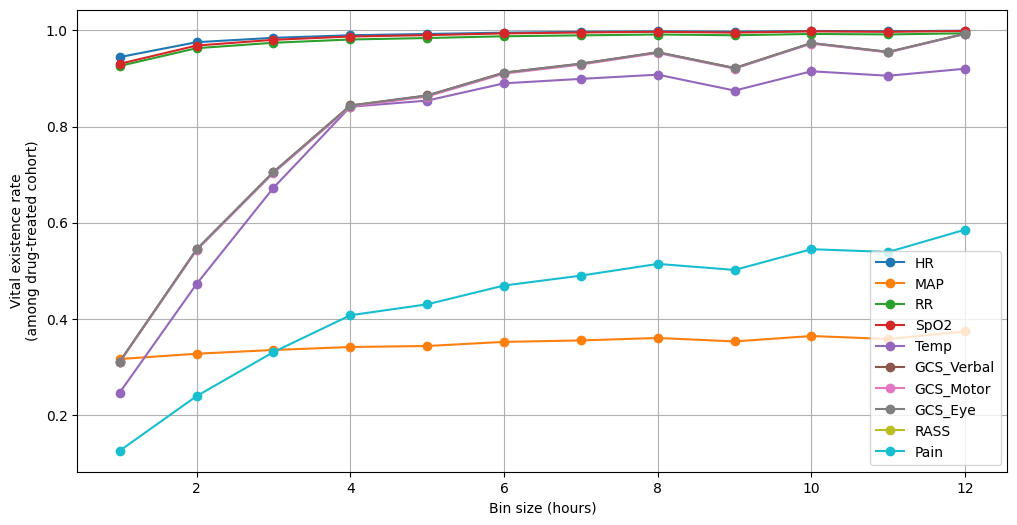

In [ ]:
# 시각화
plt.figure(figsize=(12,6))

for name in bin_results.keys():
    plt.plot(
        bin_results[name]['bin_hours'],
        bin_results[name]['exist_ratio'],
        marker='o',
        label=name
    )

plt.xlabel('Bin size (hours)')
plt.ylabel('Vital existence rate\n(among drug-treated cohort)')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

In [ ]:
# RASS itemid
RASS_ID = 228302

# 1) raw_vital에서 RASS 데이터만 추출
rass_df = raw_vital[raw_vital['itemid'] == RASS_ID]

print("RASS 전체 row 수:", len(rass_df))

# 2) valuenum이 실제로 존재하는 것만 세기
rass_nonnull = rass_df['valuenum'].notna().sum()
print("valuenum NOT NULL(실제 값 존재):", rass_nonnull)

# 3) stay_id 기준으로 RASS가 한 번이라도 기록된 환자 수
rass_stay_count = rass_df['stay_id'].nunique()
print("RASS가 존재하는 stay 수:", rass_stay_count)

# 4) 전체 final_cohort 대비 비율
total_stay = final_cohort['stay_id'].nunique()
print("전체 코호트 stay 수:", total_stay)
print(f"RASS 기록 있는 stay 비율: {rass_stay_count / total_stay * 100:.2f}%")

# 5) RASS 값 분포도(optional)
print("\n RASS 값 분포:")
print(rass_df['valuenum'].value_counts().sort_index())

🔍 RASS 전체 row 수: 0
✔ valuenum NOT NULL(실제 값 존재): 0
✔ RASS가 존재하는 stay 수: 0
전체 코호트 stay 수: 18123
✔ RASS 기록 있는 stay 비율: 0.00%

📌 RASS 값 분포:
Series([], Name: count, dtype: int64)


▶ Processing HR (220045) ...


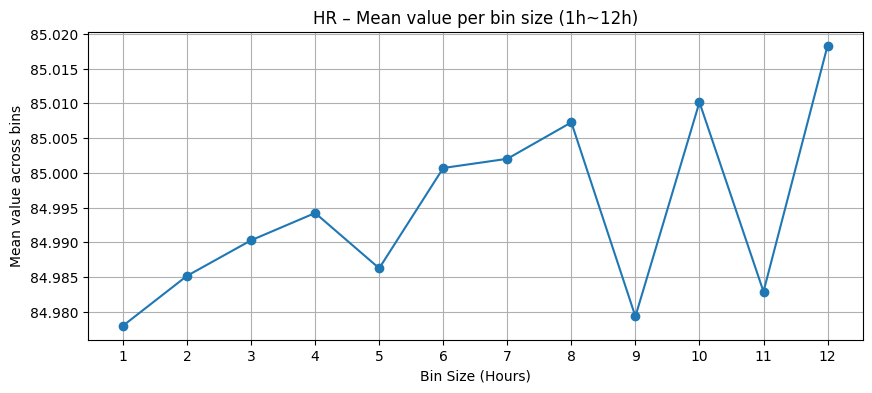

▶ Processing MAP (220052) ...


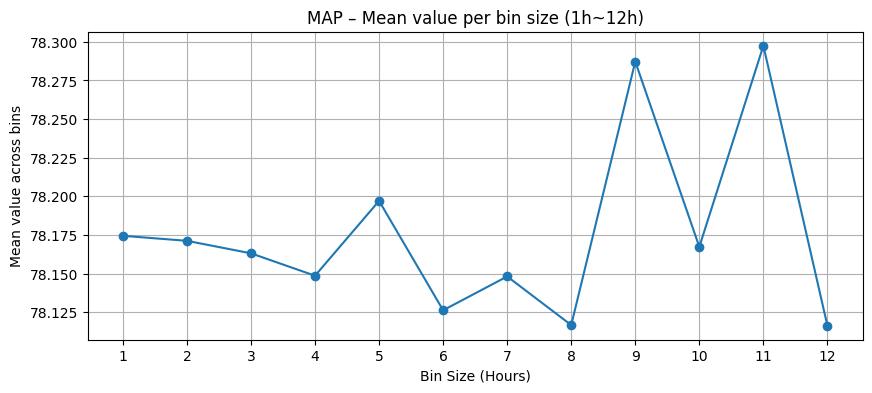

▶ Processing RR (220210) ...


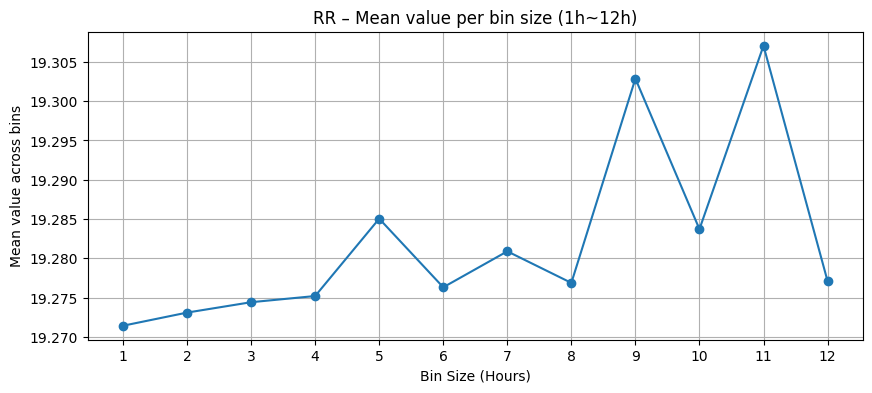

▶ Processing SpO2 (220277) ...


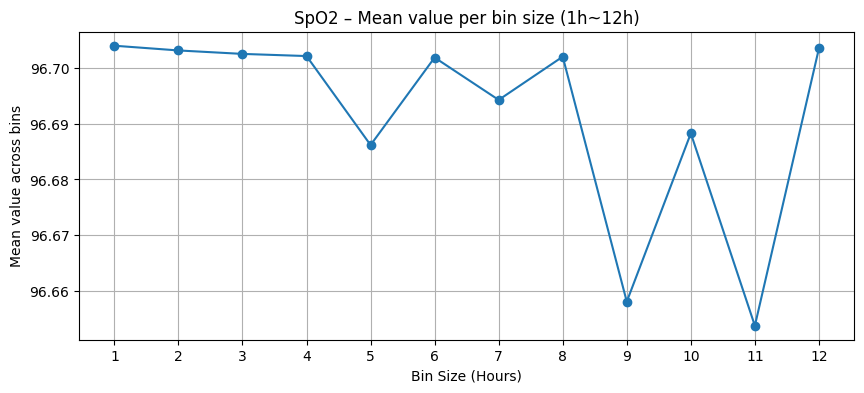

▶ Processing Temp (223761) ...


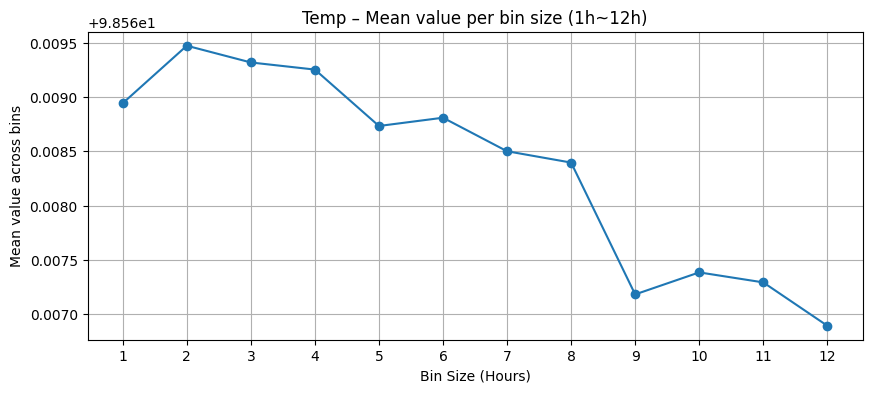

▶ Processing GCS_V (223900) ...


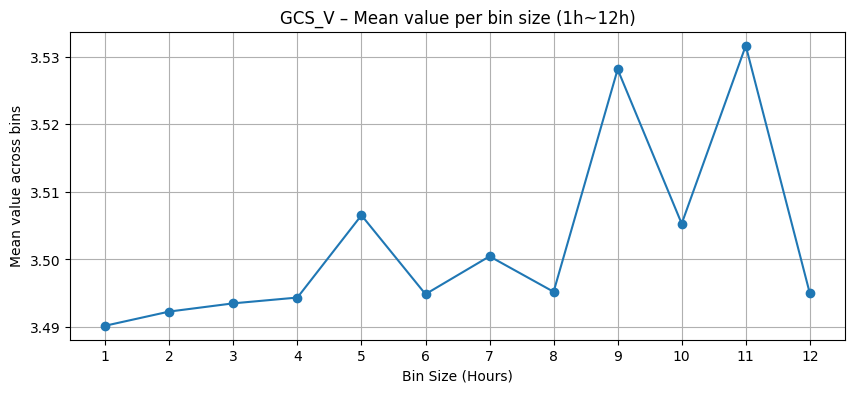

▶ Processing GCS_M (223901) ...


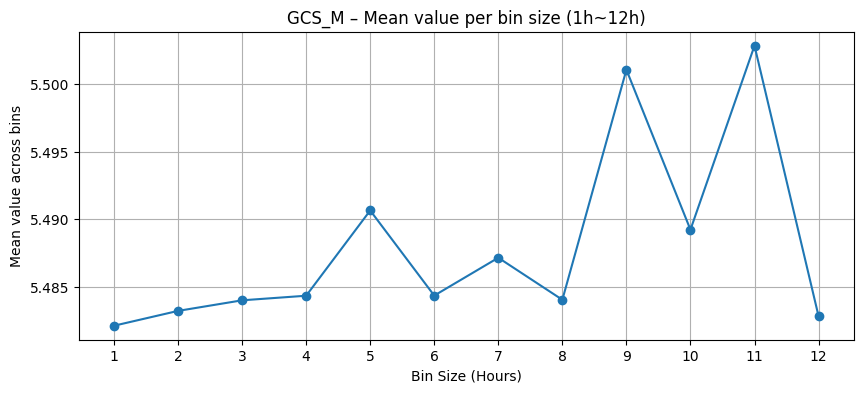

▶ Processing GCS_E (220739) ...


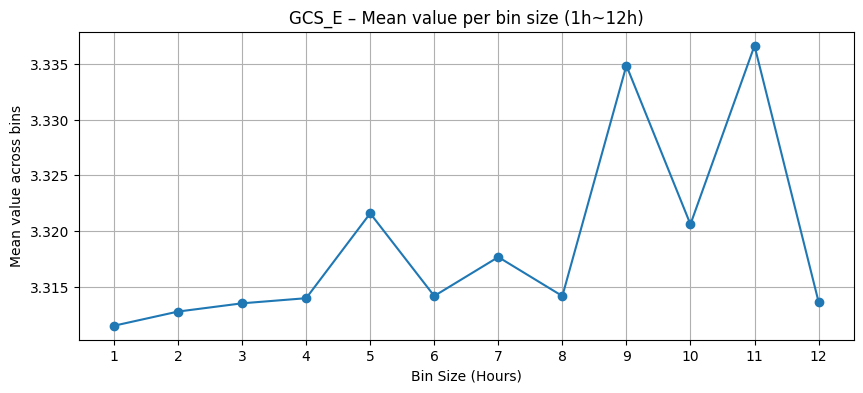

▶ Processing Pain (223791) ...


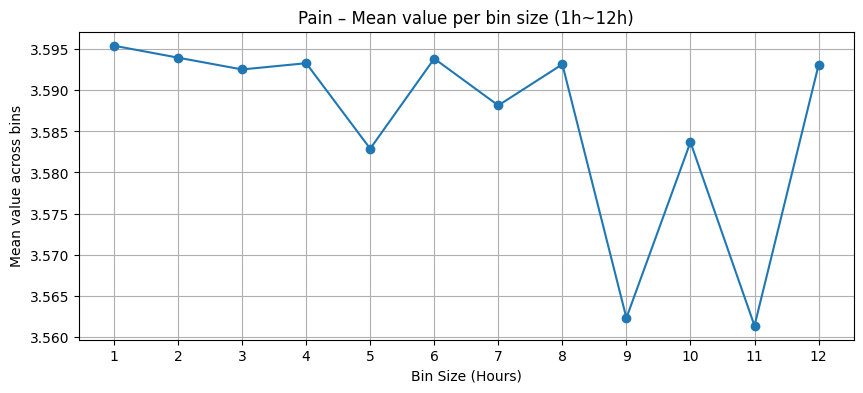

In [ ]:
# vital 리스트 (RASS 제외)
vital_itemids_all = {
    220045: 'HR',
    220052: 'MAP',
    220210: 'RR',
    220277: 'SpO2',
    223761: 'Temp',
    223900: 'GCS_V',
    223901: 'GCS_M',
    220739: 'GCS_E',
    223791: 'Pain'
}

def compute_bin_means(df, max_bin=12):
    results = []

    for hours in range(1, max_bin + 1):

        # bin 기준 생성
        bin_edges = np.arange(0, 48 + hours, hours)

        df_tmp = df.copy()
        df_tmp['bin'] = pd.cut(
            df_tmp['hour_from_start'],
            bins=bin_edges,
            labels=False,
            include_lowest=True
        )

        # bin별 mean 생성
        bin_mean = df_tmp.groupby('bin')['valuenum'].mean()

        # 전체 bin 평균 다시 평균 → "해당 bin hours에서의 평균적인 측정값"
        agg_mean = bin_mean.mean()

        results.append({
            "bin_hours": hours,
            "mean_val": agg_mean
        })

    return pd.DataFrame(results)

# Vital 각각 그래프 생성
for itemid, name in vital_itemids_all.items():
    print(f"▶ Processing {name} ({itemid}) ...")

    df_sub = raw_vital[raw_vital['itemid'] == itemid][['hour_from_start','valuenum']]

    if df_sub.empty:
        print(f"⚠ {name} has no data, skipping.")
        continue

    df_res = compute_bin_means(df_sub)

    plt.figure(figsize=(10, 4))
    plt.plot(df_res["bin_hours"], df_res["mean_val"], marker='o')
    plt.title(f"{name} – Mean value per bin size (1h~12h)")
    plt.xlabel("Bin Size (Hours)")
    plt.ylabel("Mean value across bins")
    plt.grid(True)
    plt.xticks(range(1, 13))
    plt.show()

# Vital 9종에 대한 48시간 윈도우 기준 피처 생성

In [ ]:
# 48시간 Window Summary (mean/min/max/std) 생성 — Vital 9종

# RASS 제거 후 사용할 vital & GCS & Pain 목록
vital_itemids_48h = {
    220045: 'HR',
    220052: 'MAP',
    220210: 'RR',
    220277: 'SpO2',
    223761: 'Temp',
    223791: 'Pain',
    220739: 'GCS_Eye',
    223900: 'GCS_Verbal',
    223901: 'GCS_Motor'
}

summary_feature_list = []

for itemid, vname in vital_itemids_48h.items():
    print(f"[48h Summary] Processing {vname} ({itemid}) ...")

    df_sub = raw_vital[raw_vital['itemid'] == itemid].copy()
    if df_sub.empty:
        print(f"⚠ {vname} has no data, skipping.")
        continue

    # stay_id 기준 집계
    summary = df_sub.groupby('stay_id')['valuenum'].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )

    # 컬럼명 prefix 설정
    summary = summary.add_prefix(f"{vname}_48h_")

    summary_feature_list.append(summary)

# 모든 48h Summary feature 병합
vital_48h_summary_feature = reduce(
    lambda left, right: left.join(right, how='outer'),
    summary_feature_list
)

print("Final 48h summary feature shape:", vital_48h_summary_feature.shape)
vital_48h_summary_feature.head()

[48h Summary] Processing HR (220045) ...
[48h Summary] Processing MAP (220052) ...
[48h Summary] Processing RR (220210) ...
[48h Summary] Processing SpO2 (220277) ...
[48h Summary] Processing Temp (223761) ...
[48h Summary] Processing Pain (223791) ...
[48h Summary] Processing GCS_Eye (220739) ...
[48h Summary] Processing GCS_Verbal (223900) ...
[48h Summary] Processing GCS_Motor (223901) ...
Final 48h summary feature shape: (18123, 36)


,HR_48h_mean,HR_48h_min,HR_48h_max,HR_48h_std,MAP_48h_mean,MAP_48h_min,MAP_48h_max,MAP_48h_std,RR_48h_mean,RR_48h_min,...,GCS_Eye_48h_max,GCS_Eye_48h_std,GCS_Verbal_48h_mean,GCS_Verbal_48h_min,GCS_Verbal_48h_max,GCS_Verbal_48h_std,GCS_Motor_48h_mean,GCS_Motor_48h_min,GCS_Motor_48h_max,GCS_Motor_48h_std
stay_id,,,,,,,,,,,,,,,,,,,,,
30001336,62.062500,53.0,73.0,4.909419,NaN,NaN,NaN,NaN,24.840000,15.0,...,4.0,0.000000,5.000000,5.0,5.0,0.000000,6.000000,6.0,6.0,0.000000
30001471,84.803922,66.0,107.0,9.335994,NaN,NaN,NaN,NaN,17.607843,8.0,...,4.0,0.375534,4.000000,4.0,4.0,0.000000,6.000000,6.0,6.0,0.000000
30003087,90.734694,67.0,141.0,16.900167,NaN,NaN,NaN,NaN,16.979592,13.0,...,4.0,0.452267,2.750000,1.0,4.0,1.422226,5.416667,5.0,6.0,0.514929
30003306,60.610390,60.0,80.0,2.461043,61.0,60.0,62.0,1.0,16.324675,9.0,...,4.0,0.000000,4.181818,4.0,5.0,0.404520,6.000000,6.0,6.0,0.000000
30004306,95.875000,61.0,115.0,14.127872,NaN,NaN,NaN,NaN,16.636364,12.0,...,4.0,0.223607,4.300000,4.0,5.0,0.470162,6.000000,6.0,6.0,0.000000


GCS 3종 변수의 std 제거

In [ ]:
# 제거할 std 컬럼 자동 탐색
gcs_std_cols = [col for col in vital_48h_summary_feature.columns
                if col.startswith(("GCS_Eye_48h_std", "GCS_Verbal_48h_std", "GCS_Motor_48h_std"))]

print("제거될 GCS std 컬럼:", gcs_std_cols)

# 컬럼 제거
vital_48h_summary_feature = vital_48h_summary_feature.drop(columns=gcs_std_cols)

print("제거 후 shape:", vital_48h_summary_feature.shape)

제거될 GCS std 컬럼: ['GCS_Eye_48h_std', 'GCS_Verbal_48h_std', 'GCS_Motor_48h_std']
제거 후 shape: (18123, 33)


MAP, Pain 변수 제거

In [ ]:
# 제거할 변수 리스트
vars_to_drop = ["MAP", "Pain"]

# 제거할 컬럼 수집
cols_to_drop = []
for v in vars_to_drop:
    prefix = f"{v}_48h_"
    drop_list = [col for col in vital_48h_summary_feature.columns if col.startswith(prefix)]
    cols_to_drop.extend(drop_list)

print("제거될 컬럼:", cols_to_drop)

# 실제 제거
vital_48h_summary_feature = vital_48h_summary_feature.drop(columns=cols_to_drop)

print("제거 후 shape:", vital_48h_summary_feature.shape)
vital_48h_summary_feature.head()

제거될 컬럼: ['MAP_48h_mean', 'MAP_48h_min', 'MAP_48h_max', 'MAP_48h_std', 'Pain_48h_mean', 'Pain_48h_min', 'Pain_48h_max', 'Pain_48h_std']
제거 후 shape: (18123, 25)


,HR_48h_mean,HR_48h_min,HR_48h_max,HR_48h_std,RR_48h_mean,RR_48h_min,RR_48h_max,RR_48h_std,SpO2_48h_mean,SpO2_48h_min,...,Temp_48h_std,GCS_Eye_48h_mean,GCS_Eye_48h_min,GCS_Eye_48h_max,GCS_Verbal_48h_mean,GCS_Verbal_48h_min,GCS_Verbal_48h_max,GCS_Motor_48h_mean,GCS_Motor_48h_min,GCS_Motor_48h_max
stay_id,,,,,,,,,,,,,,,,,,,,,
30001336,62.062500,53.0,73.0,4.909419,24.840000,15.0,34.0,4.017106,96.061224,92.0,...,0.167649,4.000000,4.0,4.0,5.000000,5.0,5.0,6.000000,6.0,6.0
30001471,84.803922,66.0,107.0,9.335994,17.607843,8.0,27.0,4.331644,92.490196,88.0,...,0.454189,3.846154,3.0,4.0,4.000000,4.0,4.0,6.000000,6.0,6.0
30003087,90.734694,67.0,141.0,16.900167,16.979592,13.0,35.0,4.155768,96.729167,90.0,...,0.393585,3.250000,3.0,4.0,2.750000,1.0,4.0,5.416667,5.0,6.0
30003306,60.610390,60.0,80.0,2.461043,16.324675,9.0,36.0,4.640898,96.376623,76.0,...,0.591031,4.000000,4.0,4.0,4.181818,4.0,5.0,6.000000,6.0,6.0
30004306,95.875000,61.0,115.0,14.127872,16.636364,12.0,23.0,2.479352,98.375000,94.0,...,0.207145,3.950000,3.0,4.0,4.300000,4.0,5.0,6.000000,6.0,6.0


남은 변수들에 대해, 이 중 하나라도 측정값이 없는 환자는 제거

In [ ]:
# 남아있는 vital 목록
remaining_vars = ['HR', 'RR', 'SpO2', 'Temp', 'GCS_Eye', 'GCS_Verbal', 'GCS_Motor']

# 결측 여부를 확인할 컬럼(mean만 사용)
check_cols = [f"{v}_48h_mean" for v in remaining_vars]

print("결측 여부 체크 대상 컬럼:", check_cols)

# 결측이 하나라도 있는 행 마스크
missing_mask = vital_48h_summary_feature[check_cols].isna().any(axis=1)

print("결측 환자 수:", missing_mask.sum())

# 결측이 있는 환자 제거
vital_48h_summary_feature = vital_48h_summary_feature[~missing_mask].copy()

print("결측 환자 제거 후 shape:", vital_48h_summary_feature.shape)

결측 여부 체크 대상 컬럼: ['HR_48h_mean', 'RR_48h_mean', 'SpO2_48h_mean', 'Temp_48h_mean', 'GCS_Eye_48h_mean', 'GCS_Verbal_48h_mean', 'GCS_Motor_48h_mean']
결측 환자 수: 540
결측 환자 제거 후 shape: (17583, 25)


In [ ]:
vital_48h_summary_feature.isnull().sum()

,0
HR_48h_mean,0
HR_48h_min,0
HR_48h_max,0
HR_48h_std,0
RR_48h_mean,0
RR_48h_min,0
RR_48h_max,0
RR_48h_std,3
SpO2_48h_mean,0
SpO2_48h_min,0


std nan값 0으로 채우기

In [ ]:
# 1) std 컬럼만 선택
std_cols = [col for col in vital_48h_summary_feature.columns
            if col.endswith("_48h_std")]

print("std 채울 컬럼:", std_cols)

# 2) std NaN 값을 0으로 대체
vital_48h_summary_feature[std_cols] = (
    vital_48h_summary_feature[std_cols].fillna(0)
)

std 채울 컬럼: ['HR_48h_std', 'RR_48h_std', 'SpO2_48h_std', 'Temp_48h_std']


# Vital 피처 병합

In [ ]:
# vital summary에서 살아남은 stay_id
valid_stay_ids = vital_48h_summary_feature.index

# final_cohort도 동일한 stay_id로 필터링
final_cohort = final_cohort.loc[valid_stay_ids]

# 병합
merged_df = final_cohort.join(vital_48h_summary_feature, how='inner')

print("merged_df shape:", merged_df.shape)

merged_df shape: (17583, 55)


In [ ]:
save_path = "/content/drive/MyDrive/Colab/DataAnalytics/processed/base_and_vital_final.csv"
merged_df.to_csv(save_path, index=True)
print("Saved:", save_path)

Saved: /content/drive/MyDrive/Colab/DataAnalytics/processed/base_and_vital_final.csv
